In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("stock_dataset_dirty.csv")

df.head()

,Date,Symbol,Open,High,Low,Close,Volume,Market_Cap,Sector,Profit_Margin
0,2023-01-01,AMZN,472.847313,395.110972,123.867217,312.916750,428910,2.563560,Retail,13.505575
1,2023-01-02,TSLA,326.053273,134.194156,340.825590,141.306004,969485,1.968346,Finance,26.398130
2,2023-01-03,GOOGL,378.660330,133.858975,482.565246,169.009551,255063,2.588029,Energy,15.866954
3,2023-01-04,TSLA,468.999752,109903.932470,170.092522,327.189719,887733,2.152978,Tech,9.820990
4,2023-01-05,TSLA,382.895454,492.383066,408.075071,218.543045,783970,1.684139,Tech,9.777641


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1020 non-null   str    
 1   Symbol         1020 non-null   str    
 2   Open           1000 non-null   float64
 3   High           1000 non-null   float64
 4   Low            1020 non-null   float64
 5   Close          1020 non-null   float64
 6   Volume         1020 non-null   int64  
 7   Market_Cap     1020 non-null   float64
 8   Sector         1020 non-null   str    
 9   Profit_Margin  1020 non-null   float64
dtypes: float64(6), int64(1), str(3)
memory usage: 79.8 KB


,Open,High,Low,Close,Volume,Market_Cap,Profit_Margin
count,1000.000000,1000.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000
mean,300.574438,566.074799,292.686486,296.245551,546374.051961,1.992106,17.087029
std,117.130249,5865.208202,113.889313,114.439984,265163.624615,0.575427,7.115731
min,101.852809,105.054551,95.004596,100.012288,100363.000000,1.007837,5.006025
25%,194.666214,210.093475,192.764438,199.247649,316728.750000,1.486922,10.966898
50%,303.377972,307.703455,294.700725,293.419365,533572.000000,1.987401,16.994874
75%,400.259805,410.463924,391.404735,391.815112,784707.000000,2.481606,22.924993
max,499.765490,150000.435673,489.825293,499.099756,998704.000000,2.998921,29.972617


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values("Date")

df.head()

,Date,Symbol,Open,High,Low,Close,Volume,Market_Cap,Sector,Profit_Margin
0,2023-01-01,AMZN,472.847313,395.110972,123.867217,312.916750,428910,2.563560,Retail,13.505575
1000,2023-01-01,AMZN,472.847313,395.110972,123.867217,312.916750,428910,2.563560,Retail,13.505575
1001,2023-01-02,TSLA,326.053273,134.194156,340.825590,141.306004,969485,1.968346,Finance,26.398130
1,2023-01-02,TSLA,326.053273,134.194156,340.825590,141.306004,969485,1.968346,Finance,26.398130
2,2023-01-03,GOOGL,378.660330,133.858975,482.565246,169.009551,255063,2.588029,Energy,15.866954


In [5]:
df.isnull().sum()

Date              0
Symbol            0
Open             20
High             20
Low               0
Close             0
Volume            0
Market_Cap        0
Sector            0
Profit_Margin     0
dtype: int64

In [6]:
num_cols = ['Open','High','Low','Close','Volume','Market_Cap','Profit_Margin']

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [7]:
df['Sector'] = df['Sector'].fillna(df['Sector'].mode()[0])
df['Symbol'] = df['Symbol'].fillna(df['Symbol'].mode()[0])

In [8]:
df.isnull().sum()

Date             0
Symbol           0
Open             0
High             0
Low              0
Close            0
Volume           0
Market_Cap       0
Sector           0
Profit_Margin    0
dtype: int64

In [9]:
df.duplicated().sum()

df = df.drop_duplicates()

In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()

df.head()

,Date,Symbol,Open,High,Low,Close,Volume,Market_Cap,Sector,Profit_Margin,Year,Month,Day,Day_Name
0,2023-01-01,AMZN,472.847313,395.110972,123.867217,312.916750,428910,2.563560,Retail,13.505575,2023,1,1,Sunday
1001,2023-01-02,TSLA,326.053273,134.194156,340.825590,141.306004,969485,1.968346,Finance,26.398130,2023,1,2,Monday
2,2023-01-03,GOOGL,378.660330,133.858975,482.565246,169.009551,255063,2.588029,Energy,15.866954,2023,1,3,Tuesday
3,2023-01-04,TSLA,468.999752,109903.932470,170.092522,327.189719,887733,2.152978,Tech,9.820990,2023,1,4,Wednesday
1003,2023-01-04,TSLA,468.999752,109.903932,170.092522,327.189719,887733,2.152978,Tech,9.820990,2023,1,4,Wednesday


In [11]:
##
# 
# Average Closing Price by Company
group_symbol = df.groupby("Symbol")["Close"].mean()

print(group_symbol)

Symbol
AAPL     297.685663
AMZN     292.600684
GOOGL    292.723883
MSFT     295.416597
TSLA     303.527524
Name: Close, dtype: float64


In [12]:
sector_profit = df.groupby("Sector")["Profit_Margin"].mean()

print(sector_profit)

Sector
Energy     17.810481
Finance    17.084998
Retail     17.169298
Tech       16.279116
Name: Profit_Margin, dtype: float64


In [13]:
volume_symbol = df.groupby("Symbol")["Volume"].sum()

print(volume_symbol)

Symbol
AAPL     109961827
AMZN     116972473
GOOGL    106568815
MSFT     100428282
TSLA     112881923
Name: Volume, dtype: int64


In [14]:

#Average Closing Price by Symbol and Sector
pivot_table = pd.pivot_table(df,
                             values="Close",
                             index="Symbol",
                             columns="Sector",
                             aggfunc="mean")

print(pivot_table)

Sector      Energy     Finance      Retail        Tech
Symbol                                                
AAPL    320.384623  306.587006  289.615904  267.600190
AMZN    287.534278  309.302526  289.908609  282.533901
GOOGL   286.112448  310.681863  275.062856  292.494696
MSFT    309.948386  287.196520  295.909609  293.125352
TSLA    304.923643  261.188151  308.744659  327.212749


In [15]:
pivot_volume = pd.pivot_table(df,
                              values="Volume",
                              index="Symbol",
                              columns="Sector",
                              aggfunc="sum")

print(pivot_volume)

Sector    Energy   Finance    Retail      Tech
Symbol                                        
AAPL    27950044  30283865  26788667  24939251
AMZN    27170153  28932171  29717533  31152616
GOOGL   24083279  31430027  19328174  31727335
MSFT    19230694  32253663  24220974  24722951
TSLA    30392490  25141607  25803702  31544124


In [16]:
df.groupby("Symbol")["Volume"].sum().sort_values(ascending=False)

Symbol
AMZN     116972473
TSLA     112881923
AAPL     109961827
GOOGL    106568815
MSFT     100428282
Name: Volume, dtype: int64

In [17]:
df.groupby("Sector")["Market_Cap"].mean()

Sector
Energy     2.018276
Finance    1.998393
Retail     1.964363
Tech       1.982458
Name: Market_Cap, dtype: float64

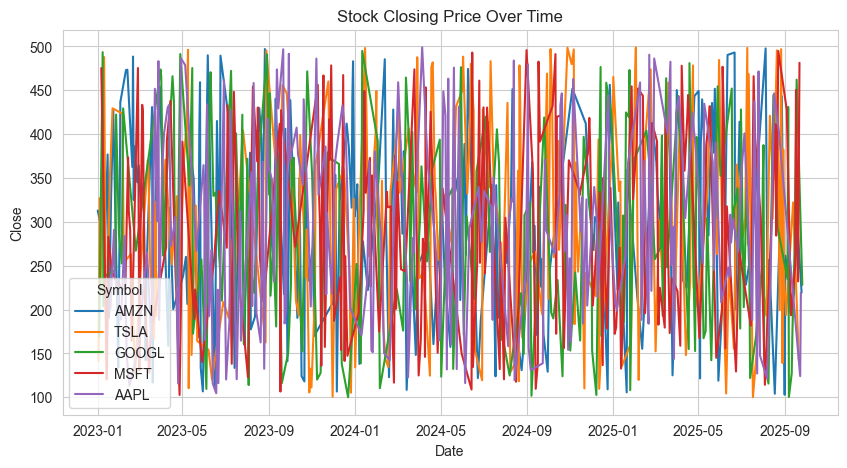

In [18]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Date", y="Close", hue="Symbol")
plt.title("Stock Closing Price Over Time")
plt.show()

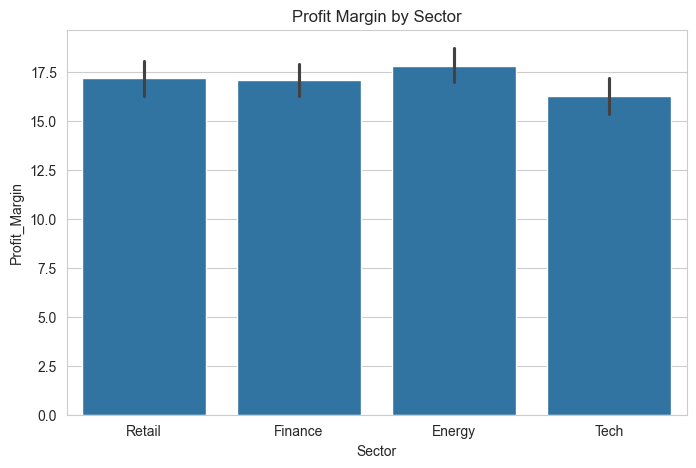

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Sector", y="Profit_Margin")
plt.title("Profit Margin by Sector")
plt.show()

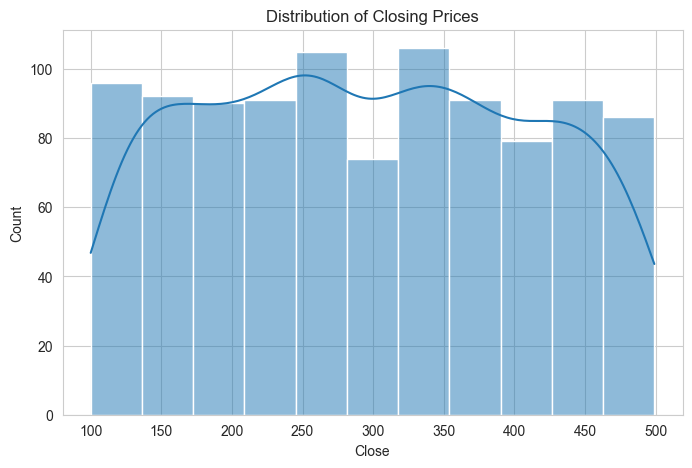

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["Close"], kde=True)
plt.title("Distribution of Closing Prices")
plt.show()

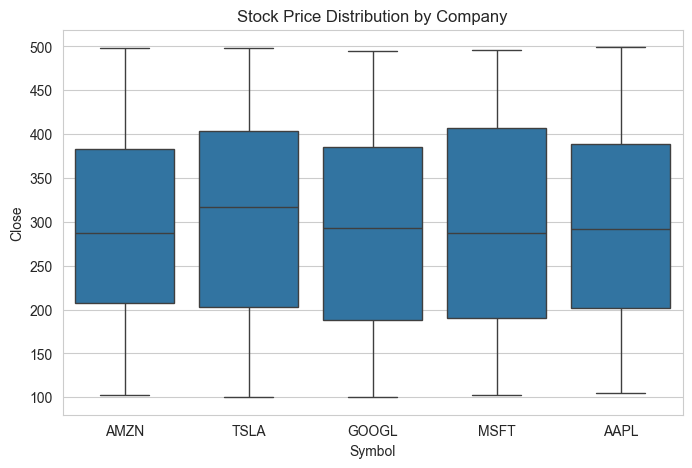

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Symbol", y="Close")
plt.title("Stock Price Distribution by Company")
plt.show()

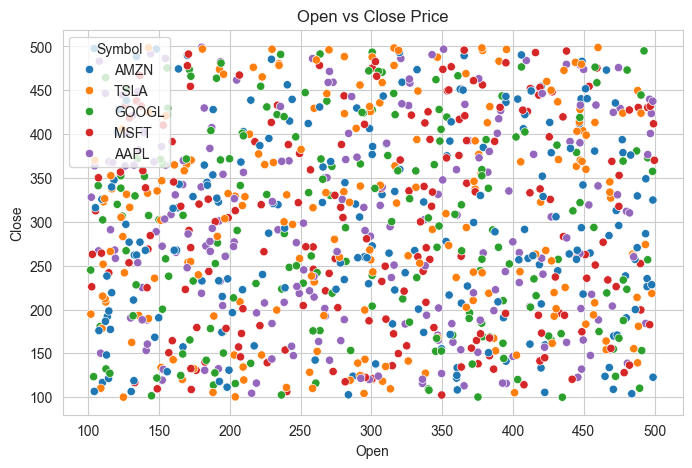

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Open", y="Close", hue="Symbol")
plt.title("Open vs Close Price")
plt.show()

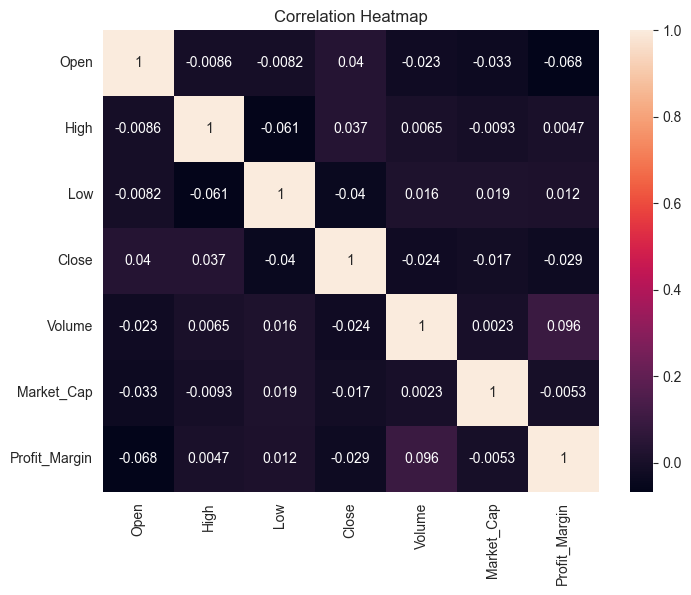

In [23]:
corr = df[['Open','High','Low','Close','Volume','Market_Cap','Profit_Margin']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()